In [2]:
import pandas as pd
import numpy as np
import ast
import os
import matplotlib.pyplot as plt
import bayesian_analysis as ba

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


In [3]:
folder = "C:\\Users\\shirl\\OneDriveCloudTemp\\P3LJ94HY\\DataShirleyMasterThesis\\DailyChallengeApp"
data_folder = 'C:\\Users\\shirl\\Documents\\Studie\\2025-2026\\Thesis\\personalized-coping-challenges\\data\\'
challenge_completions = pd.read_csv(os.path.join(folder, 'challenge_completions_30-04-2026.csv'))
participant_conditions = pd.read_csv(os.path.join(folder, 'participant_conditions_30-04-2026.csv'))
postquestions = pd.read_csv(os.path.join(folder, 'postquestions_30-04-2026.csv'))
prequestions = pd.read_csv(os.path.join(folder, 'prequestions_30-04-2026.csv'))
presented_challenges = pd.read_csv(os.path.join(folder, 'presented_challenges_30-04-2026.csv'))

### Check and remove duplicates

In [4]:
# Each participant should have one row per day in the postquestions, with consistent values for 'Likedness', 'difficulty', 'time_spent', and 'usefulness' across rows with the same 'random_id' and 'day_number'. We will check for any inconsistencies in these columns.
keys = ['random_id', 'day_number']
postquestions_columns = ['random_id', 'day_number', 'Likedness', 'difficulty', 'time_spent', 'usefulness']

# Only keep relevant columns
postquestions = postquestions[postquestions_columns] 
mismatched = postquestions.groupby(keys).filter(lambda x: x.nunique().max() > 1)

print(f"Found {len(mismatched)} rows with inconsistent ratings across keys.")
print(mismatched.sort_values(by=keys))

# We keep the last entry for each duplicate key combination, assuming it is the most recent and therefore the most accurate reflection of the participant's experience for that day.
postquestions = postquestions.drop_duplicates(subset=keys, keep='last')

Found 6 rows with inconsistent ratings across keys.
       random_id  day_number  Likedness  difficulty  time_spent  usefulness
3040  2158292523          10          3           0           1           2
3041  2158292523          10          3           0           1           3
3387  2318332676          25          4           0           2           4
3388  2318332676          25          6           0           2           4
2046  3820174326          20          7           1           1           5
2047  3820174326          20          7           1           1           4


In [5]:

keys = ['random_id', 'day_number']
presented_challenges_columns = ['random_id', 'day_number', 'challenge_id']
presented_challenges = presented_challenges[presented_challenges_columns]

mismatched = presented_challenges.groupby(keys).filter(lambda x: x.nunique().max() > 1)

print(f"Found {len(mismatched)} rows with inconsistent ratings across keys.")
print(mismatched.sort_values(by=keys))

presented_challenges = presented_challenges.drop_duplicates(subset=keys, keep='last')

Found 5511 rows with inconsistent ratings across keys.
        random_id  day_number challenge_id
2665   1178274181           6          AC7
2667   1178274181           6         AF25
2669   1178274181           6          AC7
2951   1178274181           7         AF34
2952   1178274181           7          SP9
...           ...         ...          ...
13574  9996693318          12          AC5
13575  9996693318          12         PO13
13576  9996693318          12          AC5
13577  9996693318          12         SP22
13578  9996693318          12         AF28

[5511 rows x 3 columns]


Challenge completions should not contain any duplicates where the same participant has multiple completed challenge_ids for the same day


In [6]:
keys = ['random_id', 'day_number']
challenge_completions_columns = ['random_id', 'day_number', 'challenge_id', 'challenge_category']
challenge_completions = challenge_completions[challenge_completions_columns]

mismatched = challenge_completions.groupby(keys).filter(lambda x: x.nunique().max() > 1)

print(f"Found {len(mismatched)} rows with inconsistent ratings across keys.")
print(mismatched.sort_values(by=keys))

# We keep the last entry for each duplicate key combination, assuming it is the most recent and therefore the most accurate reflection of the participant's experience for that day.
challenge_completions = challenge_completions.drop_duplicates(subset=keys, keep='last')

Found 0 rows with inconsistent ratings across keys.
Empty DataFrame
Columns: [random_id, day_number, challenge_id, challenge_category]
Index: []


The number of presented challenges should be the same as the number of filled in prequestions

In [7]:
print(f"Number of presented challenges: {len(presented_challenges)}")
print(f"Number of prequestions: {len(prequestions)}")

Number of presented challenges: 5448
Number of prequestions: 5448


### Extract completed challenge information
We merge the completed challenges with the postquestions to obtain the ratings for the challenges

In [8]:
completed_challenges = challenge_completions[['random_id', 'day_number', 'challenge_id', 'challenge_category']].copy()
completed_challenges = completed_challenges.drop_duplicates(subset=['random_id', 'day_number', 'challenge_id'])
completed_challenges = completed_challenges.merge(postquestions, on=['random_id', 'day_number'], how='left')
print("Number of challenge ratings:", len(completed_challenges))
completed_challenges.head()

Number of challenge ratings: 3535


,random_id,day_number,challenge_id,challenge_category,Likedness,difficulty,time_spent,usefulness
0,3862670812,1,SP7,social_support,0.0,0.0,0.0,1.0
1,2283685875,1,AF23,distraction,9.0,1.0,20.0,7.0
2,6560911656,1,AF23,distraction,8.0,1.0,23.0,5.0
3,1274210211,1,SP11,social_support,6.0,6.0,7.0,5.0
4,6071243457,1,PO15,problem_solving,8.0,1.0,1.0,6.0


### Extract relevant data

In [9]:
def get_condition(row):
    day = row['day_number']
    order_list = row['within_order']
    
    if day <= 5:
        return 'w0'
    
    idx = ((day - 1) // 5) - 1
    
    try:
        return order_list[idx]
    except (IndexError, TypeError):
        return None

In [ ]:
prequestions_cols = ['random_id', 'day_number', 'TIR', 'MOT', 'GOOD', 'TIME_Q', 'PAY']
df_samples = prequestions[prequestions_cols].copy()

# Merge participant conditions to get between_condition and within_order
df_samples = df_samples.merge(participant_conditions[['random_id', 'between_condition', 'within_order']], on='random_id', how='left')
df_samples['within_order'] = df_samples['within_order'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)
df_samples['within_condition'] = df_samples.apply(lambda row: get_condition(row), axis=1)

# Save initial states distribution for Day 1 for all users, regardless of their condition
initial_states = df_samples[df_samples['day_number'] == 1]
initial_states[['random_id', 'TIR', 'MOT', 'GOOD', 'TIME_Q', 'PAY']].to_csv(os.path.join(data_folder, 'initial_states_distribution.csv'), index=False)

# Merge with presented challenges to get challenge_id for each sample
presented_no_duplicates = presented_challenges.drop_duplicates(subset=['random_id', 'day_number', 'challenge_id'])
df_samples = df_samples.merge(presented_no_duplicates[['random_id', 'day_number', 'challenge_id']], on=['random_id', 'day_number'], how='left')

# Mark everything in the completed df as 1
completed_challenges['completed'] = 1

# Merge challenge completions
df_samples = df_samples.merge(
    completed_challenges[['random_id', 'day_number', 'challenge_id', 'completed']], 
    on=['random_id', 'day_number', 'challenge_id'], 
    how='left'
)

# Fill not completed challenges with 0
df_samples['completed'] = df_samples['completed'].fillna(0).astype(int)

# Merge with challenge_df to get postquestion ratings for each sample, we merge on user and day number to get the correct ratings
df_samples = df_samples.merge(
    completed_challenges[['random_id', 'day_number', 'Likedness', 'difficulty', 'time_spent', 'usefulness']],
    on=['random_id', 'day_number'],
    how='left'
)

# Set postquestions to NaN for non-completed challenges
post_cols = ['Likedness', 'difficulty', 'time_spent', 'usefulness']
for col in post_cols:
    df_samples.loc[df_samples['completed'] == 0, col] = np.nan


df_samples = df_samples.sort_values(by=['random_id', 'day_number'])
df_samples['TIR_next'] = df_samples.groupby('random_id')['TIR'].shift(-1)
df_samples['MOT_next'] = df_samples.groupby('random_id')['MOT'].shift(-1)
df_samples['GOOD_next'] = df_samples.groupby('random_id')['GOOD'].shift(-1)
df_samples['TIME_Q_next'] = df_samples.groupby('random_id')['TIME_Q'].shift(-1)
df_samples['PAY_next'] = df_samples.groupby('random_id')['PAY'].shift(-1)

# remove rows where next state is NaN (i.e., last day for each user)
# df_samples = df_samples.dropna(subset=['TIR_next', 'MOT_next', 'GOOD_next', 'TIME_Q_next', 'PAY_next'])

print("Total number of samples:", len(df_samples))
print("Total number of users:", df_samples['random_id'].nunique())

final_columns = [
        'random_id', 'day_number', 'TIR', 'MOT', 'GOOD', 'TIME_Q', 'PAY',
        'TIR_next', 'MOT_next', 'GOOD_next', 'TIME_Q_next', 'PAY_next',
        'challenge_id', 'completed', 'Likedness', 'difficulty', 'time_spent', 'usefulness'
    ]

# Only keep samples from first 5 days (w0), and from control (w1) and explanation (w2) conditions
# TODO: also filter on between condition?
conditions_to_keep = ['w0', 'w1', 'w2']
df_final = df_samples[df_samples['within_condition'].isin(conditions_to_keep)].copy()
# print number of samples per condition
print(df_final['between_condition'].value_counts())

print("Final number of samples (filtered):", len(df_final))
print("Final number of users:", df_final['random_id'].nunique())

df_final = df_final[final_columns]
df_final = df_final.rename(columns={"Likedness" : "likedness", "random_id": "user_id"})

df_agency = df_samples[df_samples['within_condition'].isin(['w3', 'w4'])].copy() 
df_agency = df_agency.rename(columns={"Likedness" : "likedness", "random_id": "user_id"})
print("Number of samples in agency conditions (w3, w4):", len(df_agency))

df_final.head()

Total number of samples: 5448
Total number of users: 312
between_condition
b1    1161
b3    1137
b2    1125
Name: count, dtype: int64
Final number of samples (filtered): 3423
Final number of users: 312
Number of samples in agency conditions (w3, w4): 2025


,user_id,day_number,TIR,MOT,GOOD,TIME_Q,PAY,TIR_next,MOT_next,GOOD_next,TIME_Q_next,PAY_next,challenge_id,completed,likedness,difficulty,time_spent,usefulness
212,1111591584,1,5,6,6,3,6,4.0,4.0,5.0,4.0,5.0,PO19,0,NaN,NaN,NaN,NaN
429,1111591584,2,4,4,5,4,5,6.0,2.0,5.0,3.0,6.0,AC19,1,8.0,4.0,5.0,6.0
547,1111591584,3,6,2,5,3,6,4.0,5.0,5.0,5.0,6.0,AC4,1,7.0,5.0,2.0,4.0
686,1111591584,4,4,5,5,5,6,5.0,5.0,6.0,4.0,6.0,AF31,0,NaN,NaN,NaN,NaN
830,1111591584,5,5,5,6,4,6,3.0,4.0,6.0,2.0,6.0,AC5,1,8.0,6.0,3.0,6.0


In [11]:
# inspect if there are users with weird data
post_cols = ['Likedness', 'difficulty', 'time_spent', 'usefulness']
users_to_remove = []
threshold = 4
for user_id, group in df_samples.groupby('random_id'):
    row_is_identical = (group[post_cols].nunique(axis=1) == 1) & (group[post_cols].notna().any(axis=1))
    if row_is_identical.sum() >= threshold:
        print(group[row_is_identical][['day_number'] + post_cols])
        users_to_remove.append(user_id)
        print(f"User {user_id} gave identical answers across the postquestions on at least {threshold} days.")

# TODO: do we remove these users?


      day_number  Likedness  difficulty  time_spent  usefulness
1091           3        1.0         1.0         1.0         1.0
1365           5        1.0         1.0         1.0         1.0
2033           9        1.0         1.0         1.0         1.0
4071          22        1.0         1.0         1.0         1.0
User 2671338277 gave identical answers across the postquestions on at least 4 days.
      day_number  Likedness  difficulty  time_spent  usefulness
1126           5        2.0         2.0         2.0         2.0
1887          10        1.0         1.0         1.0         1.0
2257          13        5.0         5.0         5.0         5.0
3029          17        1.0         1.0         1.0         1.0
3706          21        1.0         1.0         1.0         1.0
User 8445964210 gave identical answers across the postquestions on at least 4 days.


#### Save challenge info

In [12]:
difficulty_to_score = {
    "Makkelijk": 0.33,
    "Gemiddeld": 0.66,
    "Moeilijk": 1.0
}

# TODO: Use all data or only from the ones we use in the samples as well? I.e. filter on conditions
mean_challenge_scores = completed_challenges.groupby('challenge_id')[['Likedness', 'difficulty', 'time_spent', 'usefulness']].mean()
mean_challenge_scores = mean_challenge_scores.rename(columns={
    'Likedness': 'likedness'})

# Also include mean completion rate per challenge
completion_rate_per_challenge = df_final.groupby('challenge_id')['completed'].mean()

challenge_categories = completed_challenges[['challenge_id', 'challenge_category']].drop_duplicates().set_index('challenge_id')['challenge_category']
cat_to_id = {c: i for i, c in enumerate(sorted(challenge_categories.unique()))}

# Write to challenge file
challenge_file = 'challenges_real.csv'
challenge_info = pd.read_csv(data_folder + challenge_file, delimiter=';')
challenge_info['expert_score'] = challenge_info['Moeilijkheidsgraad'].map(difficulty_to_score)

challenge_info = challenge_info.merge(mean_challenge_scores, on='challenge_id', how='outer')
challenge_info = challenge_info.merge(completion_rate_per_challenge.rename('completion_rate'), on='challenge_id', how='left')
challenge_info = challenge_info.merge(challenge_categories.rename('category'), on='challenge_id', how='left')
challenge_info['category_id'] = challenge_info['category'].map(cat_to_id)
challenge_info.rename(columns={'Likedness': 'likedness'}, inplace=True)
challenge_info.to_csv(os.path.join(data_folder, 'challenge_info.csv'), index=False)
challenge_info.head()

,challenge_id,Type,Moeilijkheidsgraad,expert_score,likedness,difficulty,time_spent,usefulness,completion_rate,category,category_id
0,AC1,Photo,Moeilijk,1.00,7.166667,2.041667,7.625000,4.458333,0.551724,acceptance,0
1,AC10,Open,Moeilijk,1.00,5.610169,3.576271,3.033898,4.355932,0.837838,acceptance,0
2,AC11,Open,Moeilijk,1.00,6.151515,2.060606,3.424242,4.303030,0.677419,acceptance,0
3,AC12,Open,Gemiddeld,0.66,5.907692,2.169231,1.892308,4.123077,0.926829,acceptance,0
4,AC13,Photo,Moeilijk,1.00,6.363636,4.545455,7.636364,4.090909,0.270270,acceptance,0


Merge challenge info into samples

In [13]:
df_final = df_final.merge(challenge_info[['challenge_id', 'category', 'category_id', 'Type', 'expert_score']], on='challenge_id', how='left')
df_final.to_csv(os.path.join(data_folder, 'processed_samples.csv'), index=False)
df_final.head()

,user_id,day_number,TIR,MOT,GOOD,TIME_Q,PAY,TIR_next,MOT_next,GOOD_next,...,challenge_id,completed,likedness,difficulty,time_spent,usefulness,category,category_id,Type,expert_score
0,1111591584,1,5,6,6,3,6,4.0,4.0,5.0,...,PO19,0,NaN,NaN,NaN,NaN,problem_solving,2,Photo,1.00
1,1111591584,2,4,4,5,4,5,6.0,2.0,5.0,...,AC19,1,8.0,4.0,5.0,6.0,acceptance,0,Open,0.66
2,1111591584,3,6,2,5,3,6,4.0,5.0,5.0,...,AC4,1,7.0,5.0,2.0,4.0,acceptance,0,Open,1.00
3,1111591584,4,4,5,5,5,6,5.0,5.0,6.0,...,AF31,0,NaN,NaN,NaN,NaN,distraction,1,Photo,0.66
4,1111591584,5,5,5,6,4,6,3.0,4.0,6.0,...,AC5,1,8.0,6.0,3.0,6.0,acceptance,0,Open,0.66


In [14]:
df_final.groupby(['Type', 'completed']).size().unstack(fill_value=0)

completed,0,1
Type,,
Open,594,1648
Photo,652,395
Quiz,7,127


In [15]:
# print per challenge, the time_spent rating and its std
df_final.groupby('challenge_id')[['time_spent', 'likedness', 'difficulty', 'usefulness']].agg(['mean', 'std'])


time_spent            likedness           difficulty            \
                   mean        std      mean       std       mean       std   
challenge_id                                                                  
AC1            9.875000  23.971859  7.500000  1.632993   1.937500  1.181454   
AC10           3.903226   6.128376  5.225806  1.856694   3.322581  2.413671   
AC11           3.900000   3.477749  6.300000  2.451637   1.200000  1.196486   
AC12           2.078947   2.561477  5.315789  2.394874   2.263158  2.250336   
AC13           7.666667   5.612486  5.777778  3.192874   4.444444  2.788867   
...                 ...        ...       ...       ...        ...       ...   
SP5            3.000000   2.503331  4.562500  2.279437   2.687500  1.922455   
SP6           27.250000  49.776166  7.062500  2.205108   2.625000  2.777889   
SP7           35.650000  46.693035  6.250000  2.953588   4.450000  3.136794   
SP8           13.750000   4.432026  6.625000  2.924649   3.750000  3.105295   
SP9            9.958333  12.953023  4.750000  2.288915   4.375000  2.683484   

             usefulness            
                   mean       std  
challenge_id                       
AC1            4.875000  1.408309  
AC10           4.032258  1.196770  
AC11           4.300000  1.417930  
AC12           3.815789  1.674212  
AC13           3.777778  1.715938  
...                 ...       ...  
SP5            4.062500  1.181454  
SP6            4.562500  1.459166  
SP7            4.000000  1.835326  
SP8            4.500000  1.309307  
SP9            3.958333  1.805286  

[103 rows x 8 columns]

### Compare adherence in agency vs. non-agency conditions

Completion rate (agency conditions): 67.41% (1365/2025)
Completion rate (no agency): 63.39% (2170/3423)
Mean of difference samples: 0.0400
Standard deviation of difference samples: 0.0132
Probability that agency condition is better: 99.88%
95% HDI: [1.44%, 6.64%]


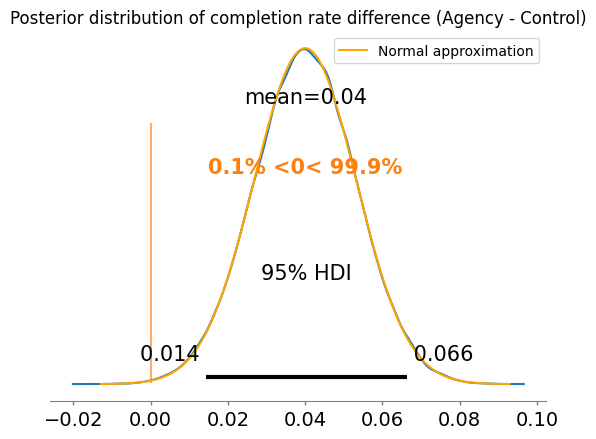

In [15]:
from scipy.stats import beta
import arviz as az
np.random.seed(42)

successes = [df_agency['completed'].sum(), df_final['completed'].sum()]
n_samples = [len(df_agency), len(df_final)]

completion_rate_agency = df_agency['completed'].mean()
print(f"Completion rate (agency conditions): {completion_rate_agency:.2%} ({successes[0]}/{n_samples[0]})")

completion_rate = df_final['completed'].mean()
print(f"Completion rate (no agency): {completion_rate:.2%} ({successes[1]}/{n_samples[1]})")

prior_a, prior_b = 1, 1

a_agency, b_agency = prior_a + successes[0], prior_b + (n_samples[0] - successes[0])
a_control, b_control = prior_a + successes[1], prior_b + (n_samples[1] - successes[1])

samples = 100000
agency_posterior = beta.rvs(a_agency, b_agency, size=samples)
control_posterior = beta.rvs(a_control, b_control, size=samples)

diff_samples = agency_posterior - control_posterior
prob_better = np.mean(diff_samples > 0)
hdi_95 = az.hdi(diff_samples, hdi_prob=0.95)
az.plot_posterior(diff_samples, ref_val=0, hdi_prob=0.95)
# approximate posterior so we can use it later for simulations
mu = np.mean(diff_samples)
sigma = np.std(diff_samples)
print(f"Mean of difference samples: {mu:.4f}")
print(f"Standard deviation of difference samples: {sigma:.4f}")
# plot normal distribution with same mean and std as diff_samples
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
plt.plot(x, (1/(sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma)**2), label='Normal approximation', color='orange')
plt.legend()
plt.title("Posterior distribution of completion rate difference (Agency - Control)")

print(f"Probability that agency condition is better: {prob_better:.2%}")
print(f"95% HDI: [{hdi_95[0]:.2%}, {hdi_95[1]:.2%}]")

In [ ]:
# Per-person completion rates
agency_rates = (
    df_agency
    .groupby("user_id")["completed"]
    .mean()
)

control_rates = (
    df_final
    .groupby("user_id")["completed"]
    .mean()
)

paired = pd.concat(
    [agency_rates, control_rates],
    axis=1,
    keys=["agency", "control"]
).dropna()

# Per-person differences
paired["diff"] = paired["agency"] - paired["control"]

diffs = paired["diff"].values

ba.paired_t_test(diffs)

              mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
improvement  0.047  0.014     0.020      0.073      0.000    0.000  2593.510   
effect_size  0.222  0.067     0.086      0.350      0.001    0.001  2373.322   

             ess_tail  r_hat  
improvement  2575.900  1.000  
effect_size  2508.423  1.002  
P(improvement > 0): 0.9998
P(Effect Size > 0.1): 0.9690
P(Effect Size > 0.2): 0.6295
P(Effect Size > 0.3): 0.1187


In [ ]:
az.plot_posterior(diffs)

### Inspect data

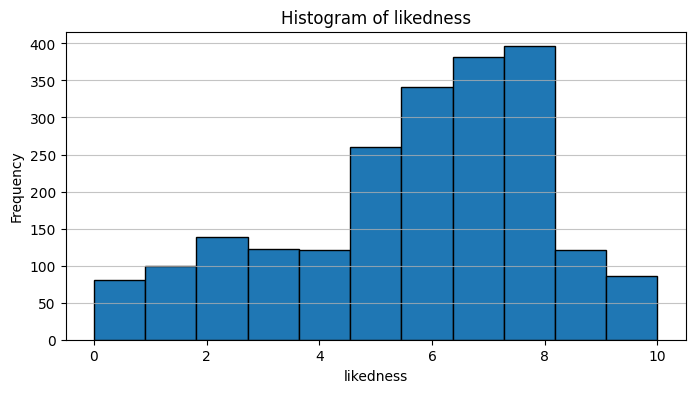

likedness - Mean: 5.75, Std: 2.53
likedness - Min: 0.00, Max: 10.00


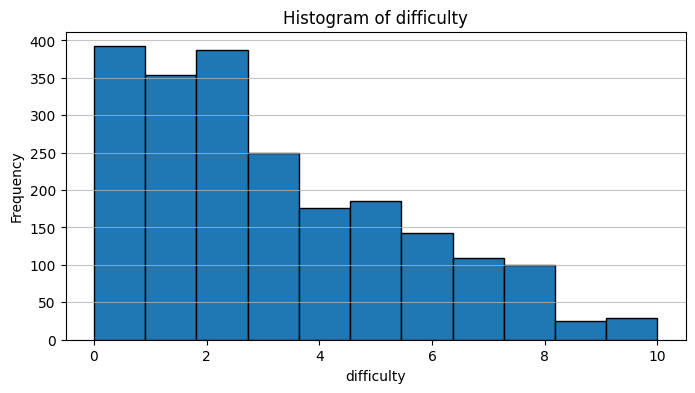

difficulty - Mean: 3.00, Std: 2.56
difficulty - Min: 0.00, Max: 10.00


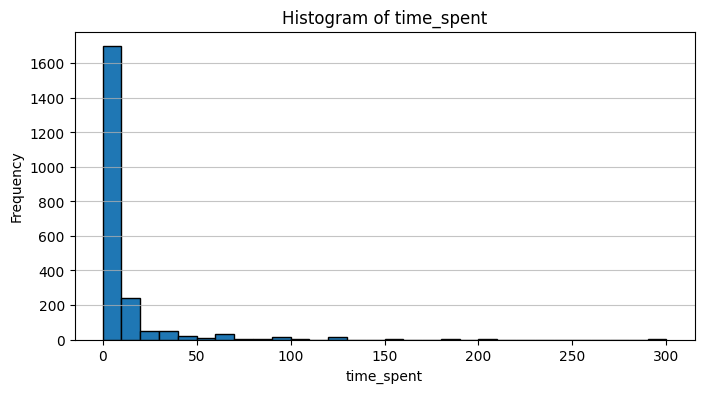

time_spent - Mean: 8.67, Std: 21.00
time_spent - Min: 0.00, Max: 300.00


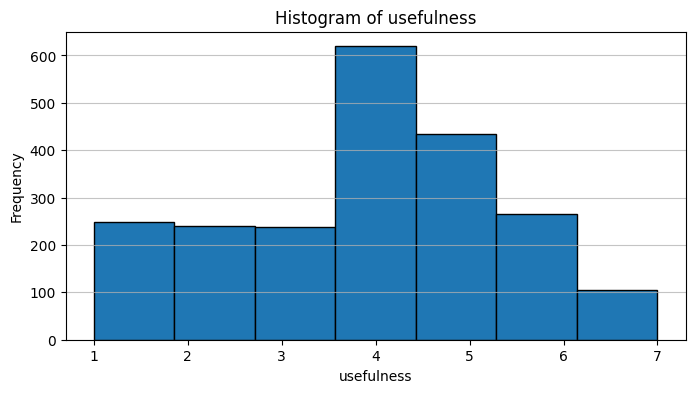

usefulness - Mean: 3.91, Std: 1.65
usefulness - Min: 1.00, Max: 7.00


In [ ]:
reward_columns = ['likedness', 'difficulty', 'time_spent', 'usefulness']
num_bins = {
    'likedness': 11,  # 0 to 10
    'difficulty': 11,   # Makkelijk, Gemiddeld, Moeilijk
    'time_spent': 30, # Assuming time spent can vary widely, we can use more bins
    'usefulness': 7   # 0 to 7
}

# plot histogram of each reward column
for col in reward_columns:
    plt.figure(figsize=(8, 4))
    plt.hist(df_final[col].dropna(), bins=num_bins[col], edgecolor='k')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.75)
    plt.show()
    # also print mean and std
    print(f"{col} - Mean: {df_final[col].mean():.2f}, Std: {df_final[col].std():.2f}")
    # and min and max
    print(f"{col} - Min: {df_final[col].min():.2f}, Max: {df_final[col].max():.2f}")

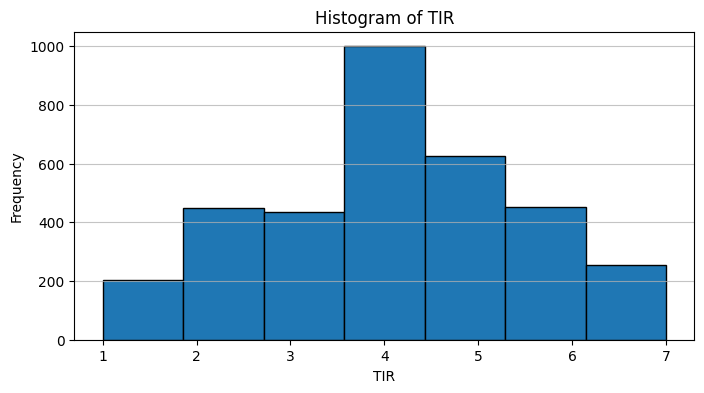

TIR - Mean: 4.10, Std: 1.60
TIR - Min: 1.00, Max: 7.00


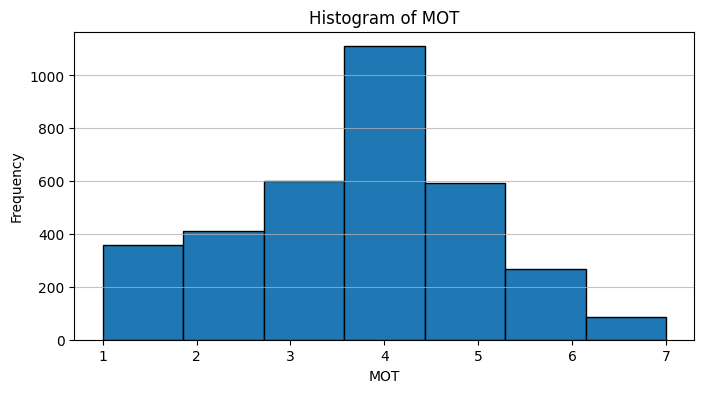

MOT - Mean: 3.68, Std: 1.48
MOT - Min: 1.00, Max: 7.00


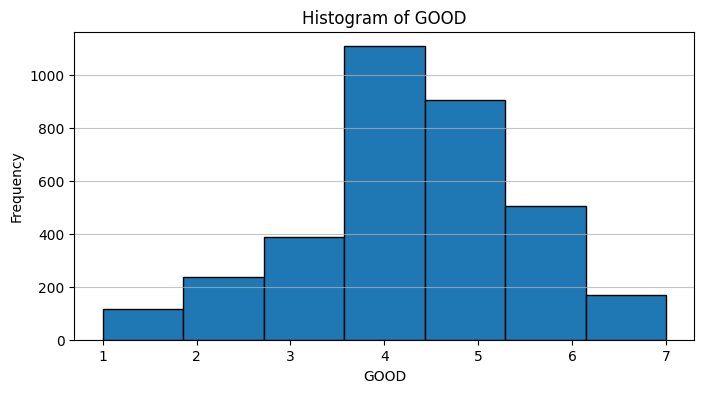

GOOD - Mean: 4.35, Std: 1.37
GOOD - Min: 1.00, Max: 7.00


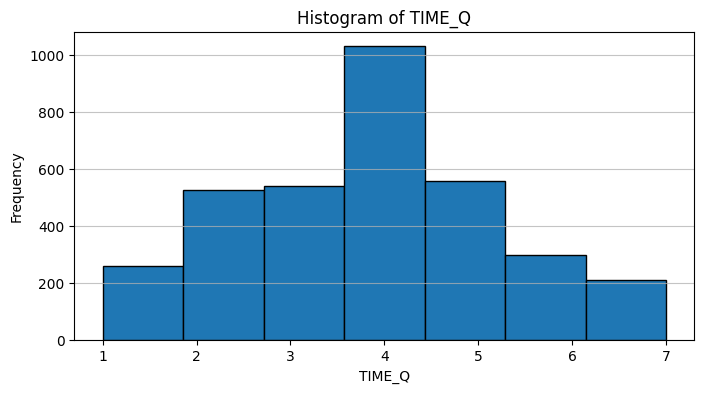

TIME_Q - Mean: 3.83, Std: 1.58
TIME_Q - Min: 1.00, Max: 7.00


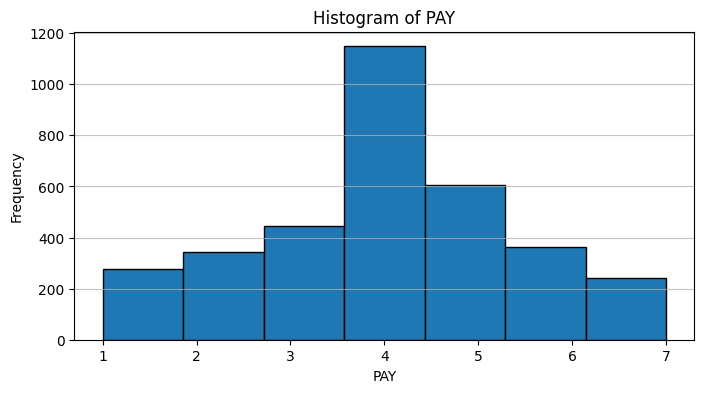

PAY - Mean: 4.02, Std: 1.58
PAY - Min: 1.00, Max: 7.00


In [ ]:
state_features = ['TIR', 'MOT', 'GOOD', 'TIME_Q', 'PAY']
for col in state_features:
    plt.figure(figsize=(8, 4))
    plt.hist(df_final[col].dropna(), bins=7, edgecolor='k')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.75)
    plt.show()
    # also print mean and std
    print(f"{col} - Mean: {df_final[col].mean():.2f}, Std: {df_final[col].std():.2f}")
    # and min and max
    print(f"{col} - Min: {df_final[col].min():.2f}, Max: {df_final[col].max():.2f}")

In [ ]:
# For every challenge_id, print the number of samples
challenge_counts = df_final['challenge_id'].value_counts()
# min and max number of samples per challenge
print(f"Min samples per challenge: {challenge_counts.min()}")
print(f"Max samples per challenge: {challenge_counts.max()}")


Min samples per challenge: 15
Max samples per challenge: 60


#### Correlations

In [ ]:
correlation_states = df_final[['TIR', 'MOT', 'GOOD', 'TIME_Q', 'PAY']].corr()
print(correlation_states)

             TIR       MOT      GOOD    TIME_Q       PAY
TIR     1.000000 -0.161232 -0.040238 -0.126056 -0.045065
MOT    -0.161232  1.000000  0.526754  0.464602  0.514494
GOOD   -0.040238  0.526754  1.000000  0.295819  0.508646
TIME_Q -0.126056  0.464602  0.295819  1.000000  0.281342
PAY    -0.045065  0.514494  0.508646  0.281342  1.000000


In [18]:
# find correlations between reward columns
reward_columns = ['likedness', 'difficulty', 'time_spent', 'usefulness', 'PAY_next', 'completed']
correlation_matrix = df_final[reward_columns].corr()
print(correlation_matrix)

            likedness  difficulty  time_spent  usefulness  PAY_next  completed
likedness    1.000000   -0.048931    0.178579    0.650594  0.153589        NaN
difficulty  -0.048931    1.000000    0.121872    0.063189  0.018669        NaN
time_spent   0.178579    0.121872    1.000000    0.155719  0.034179        NaN
usefulness   0.650594    0.063189    0.155719    1.000000  0.239928        NaN
PAY_next     0.153589    0.018669    0.034179    0.239928  1.000000   0.081999
completed         NaN         NaN         NaN         NaN  0.081999   1.000000
